# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 09: Árvores de Decisão e k-Means**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_09_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
url = "https://gist.githubusercontent.com/marcelovca90/de69333ef1e36f6ce4671e387f820f34/raw/29d61f2789c51a84144192a8127c5b041fa8bca2/wifi_localization.txt"

column_names = [ "AP1", "AP2", "AP3", "AP4", "AP5", "AP6", "AP7", "Room" ]

df = pd.read_csv(url, sep="\t", header=None, names=column_names)

X = df.drop(columns=["Room"]).values
y = df["Room"].values

feature_names = df.columns[:-1].tolist()

df.head()

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


### <font color='#2D9CDB'>Q1) O Wireless Indoor Localization [[1]](https://archive.ics.uci.edu/dataset/422/wireless+indoor+localization)[[2]](https://archive-beta.ics.uci.edu/dataset/422/wireless+indoor+localization) é um conjunto de dados amplamente utilizado em pesquisas sobre posicionamento indoor e redes sem fio. Pesquise brevemente sobre esse dataset e descreva, em um único parágrafo, qual é o problema que ele busca resolver, quais informações são registradas em cada amostra, o significado dos valores RSSI (Received Signal Strength Indicator) e por que essa base de dados pode ser utilizada tanto em problemas de classificação quanto de clusterização.</font>

**Resposta:** O Wireless Indoor Localization busca resolver problema de localização interna de dispositivos em tempo real, mapeando as potências dos sinais captados para identificar em qual sala está o dispositivo. Cada amostra registra os valores de RSSI(Received Signal Strength Indicator) coletado por sete pontos de acesso diferentes, além da variável alvo que identifica qual a sala correspondente. O RSSI indica a potência do sinal recebido em decibéis, onde valores numéros maiores representam sinais mais fortes por proximidade física e valores menores indicam sinais mais fracos e distantes. O dataset pode ser usado em problemas de classificação usando os rótulos das salas para treinar modelos que predizem a localização exata e em problemas de clusterização, agrupando os sinais por similaridade geométrica ou de potência para descobrir padrões de distribuição espacial sem depender previamente das marcações de salas.

### <font color='#2D9CDB'>Q2) Utilizando o dataset Wireless Indoor Localization já carregado, informe a quantidade total de amostras, o número de atributos, o número de classes e os identificadores das salas presentes na base de dados. Em seguida, apresente uma tabela contendo as cinco primeiras amostras do conjunto de dados. Com base nos resultados obtidos, descreva brevemente a estrutura do dataset e o significado dos atributos e da variável alvo.</font>

In [4]:
total_amostras = df.shape[0]
num_atributos = len(feature_names)
salas_unicas = np.unique(y)
num_classes = len(salas_unicas)

print(f'Quantidade de amostras: {total_amostras}')
print(f'Quantidade de atributos: {num_atributos}')
print(f'Quantidade de classes: {num_classes}')
print(f'Identificadores das salas: {salas_unicas}')

df.head(5)

Quantidade de amostras: 2000
Quantidade de atributos: 7
Quantidade de classes: 4
Identificadores das salas: [1 2 3 4]


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


**Resposta:** O dataset possui um total de duas mil amostras, 7 atributos e 4 classes diferentes, identificadas por [1, 2, 3, 4]. As colunas que podem ser usadas para predição são nomeadas de AP1 a AP7, que representam as medições de RSSI de cada ponto de acesso Wi-Fi, que são variáveis independentes, e a variável alvo Room, que indica qual cômodo a medição foi feita.

### <font color='#2D9CDB'>Q3) Utilizando apenas os atributos RSSI do dataset, apresente as estatísticas descritivas (contagem, média, desvio padrão, valor mínimo, quartis e valor máximo) de cada ponto de acesso Wi-Fi. Em seguida, identifique quais pontos de acesso apresentam, em média, os sinais mais fortes e os mais fracos. Com base nos resultados obtidos, comente brevemente sobre a variabilidade das medições de RSSI observadas no conjunto de dados.</font>

In [5]:
display(df[feature_names].describe())

medias = df[feature_names].mean()
ap_mais_forte = medias.idxmax()
ap_mais_fraco = medias.idxmin()
print(f'\n Ponto com sinal mais forte na média: {ap_mais_forte}')
print(f'\n Ponto com sinal mais fraco na média: {ap_mais_fraco}')

,AP1,AP2,AP3,AP4,AP5,AP6,AP7
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-52.330500,-55.623500,-54.964000,-53.566500,-62.640500,-80.985000,-81.726500
std,11.321677,3.417688,5.316186,11.471982,9.105093,6.516672,6.519812
min,-74.000000,-74.000000,-73.000000,-77.000000,-89.000000,-97.000000,-98.000000
25%,-61.000000,-58.000000,-58.000000,-63.000000,-69.000000,-86.000000,-87.000000
50%,-55.000000,-56.000000,-55.000000,-56.000000,-64.000000,-82.000000,-83.000000
75%,-46.000000,-53.000000,-51.000000,-46.000000,-56.000000,-77.000000,-78.000000
max,-10.000000,-45.000000,-40.000000,-11.000000,-36.000000,-61.000000,-63.000000



 Ponto com sinal mais forte na média: AP1

 Ponto com sinal mais fraco na média: AP7


**Resposta:** Com base nos resultados obtidos, é possível ver que o AP1 possui o sinal mais forte e que o AP2, AP3 e AP4 estão próximos do mesmo, uma vez que obteram valores similares. Além disso, entre esse 4 APs, AP1 possui o segundo maior desvio padrão, enquanto o AP2 e AP3 possuem valores similares de média, porém um desvio padrão menor. Além disso, AP6 e AP7 demonstram estar longe dos outros APs, possuindo uma média mais baixa, logo, um sinal mais fraco. Isso indica que os APs de 1 a 4 podem estar mais próximos entre si enquanto os APs 6 e 7 estão mais longes, causando uma queda na qualidade do sinal.

### <font color='#2D9CDB'>Q4) Construa histogramas para os sete atributos RSSI do dataset e analise a distribuição dos valores observados. Em seguida, identifique quais pontos de acesso apresentam distribuições mais concentradas e quais apresentam maior dispersão. Com base nos gráficos obtidos, discuta brevemente como essas diferenças podem influenciar tarefas de classificação e clusterização.</font>

array([[<Axes: title={'center': 'AP1'}>, <Axes: title={'center': 'AP2'}>,
        <Axes: title={'center': 'AP3'}>],
       [<Axes: title={'center': 'AP4'}>, <Axes: title={'center': 'AP5'}>,
        <Axes: title={'center': 'AP6'}>],
       [<Axes: title={'center': 'AP7'}>, <Axes: >, <Axes: >]],
      dtype=object)

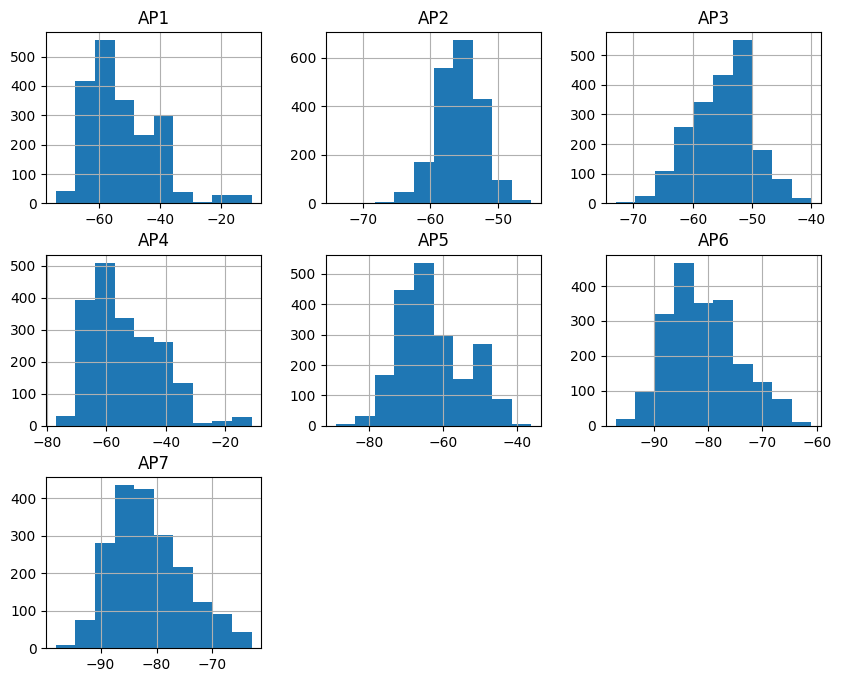

In [6]:
df[feature_names].hist(figsize=[10, 8])

**Resposta:** O AP2 possui a distribuição mais concentrada dentre todos os APs, além de possuir o maior pico. Seguido dele, os APs 4 e 6 possuem o maior espalhamento. Isso afeta uma árvore de decisão pois atributos com alta distribuições ou picos bem definidos são ótimos para a árvore criar regras de corte para fazer a classificação. Sobre a clusterização, o k-means utiliza distância Euclidiana, o que significa que se um atributo varia em uma escala muito maior ou tem um comportamento muito disperso comparado a outro, ele pode acabar distorcendo o cálculo da distância, fazendo com que o algoritmo dê mais peso para um AP do que para outro na clusterização.

### <font color='#2D9CDB'>Q5) Analise a distribuição das amostras entre as diferentes salas do dataset. Para isso, apresente a quantidade de exemplos pertencentes a cada classe e construa um gráfico de barras mostrando essa distribuição. Em seguida, informe se o conjunto de dados é balanceado e discuta brevemente como o balanceamento das classes pode influenciar o treinamento e a avaliação de modelos de classificação.</font>

Room
1    500
2    500
3    500
4    500
Name: count, dtype: int64



Text(0, 0.5, 'Quantidade de Amostras')

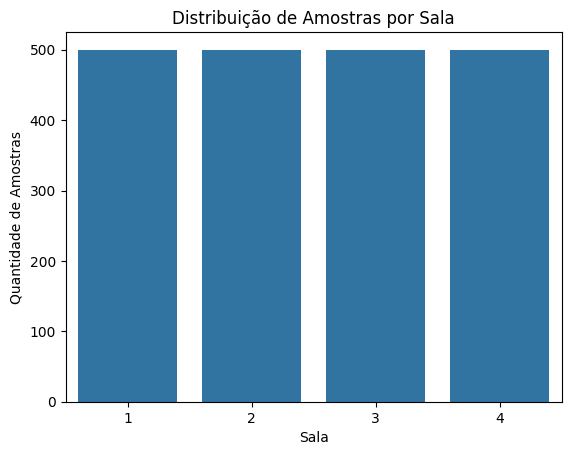

In [7]:
print(f'{df['Room'].value_counts()}\n')
sns.countplot(df, x='Room',)
plt.title('Distribuição de Amostras por Sala')
plt.xlabel('Sala')
plt.ylabel('Quantidade de Amostras')

**Resposta:** O conjunto de amostras é extremamente bem balanceado, possuindo a exata mesma quantidade(500) de amostras por sala. Isso é ótimo para o treinamento do modelo pois caso o modelo fosse desbalanceado, ele poderia aprender mais a prever uma sala específica do que as outras, o que não será o caso.

### <font color='#2D9CDB'>Q6) Divida o dataset em conjuntos de treinamento e teste utilizando 70% das amostras para treinamento e 30% para teste. Utilize estratificação para preservar a proporção das classes em ambos os conjuntos. Em seguida, informe a quantidade de amostras presente em cada conjunto e verifique se a distribuição das classes foi mantida após a divisão.</font>

In [8]:
X = df.drop('Room', axis=1)
y = df['Room']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y)

print(f"Quantidade no treino: {X_train.shape[0]}")
print(f"Quantidade no teste: {X_test.shape[0]}")

print(f"\nProporção das salas no Treino:\n{y_train.value_counts()}")
print(f"\nProporção das salas no Teste:\n{y_test.value_counts()}")

Quantidade no treino: 1400
Quantidade no teste: 600

Proporção das salas no Treino:
Room
2    350
3    350
1    350
4    350
Name: count, dtype: int64

Proporção das salas no Teste:
Room
4    150
2    150
3    150
1    150
Name: count, dtype: int64


**Resposta:** A proporção treino-teste foi mantida após a divisão do dataset.

# <font color='green'><u><b>Parte 2 - Árvore de Decisão</b></u></font>

### <font color='#2D9CDB'>Q7) Treine uma árvore de decisão para classificar as salas do dataset utilizando os dados de treinamento. Em seguida, informe a profundidade da árvore, o número de nós folha e apresente uma visualização da estrutura aprendida pelo modelo. Com base na árvore obtida, identifique qual atributo foi utilizado no nó raiz e discuta brevemente o que isso indica sobre sua importância para o processo de classificação.</font>

Profundidade da árvore: 12
Número de nós folha: 31
Atributo do nó raiz: AP1


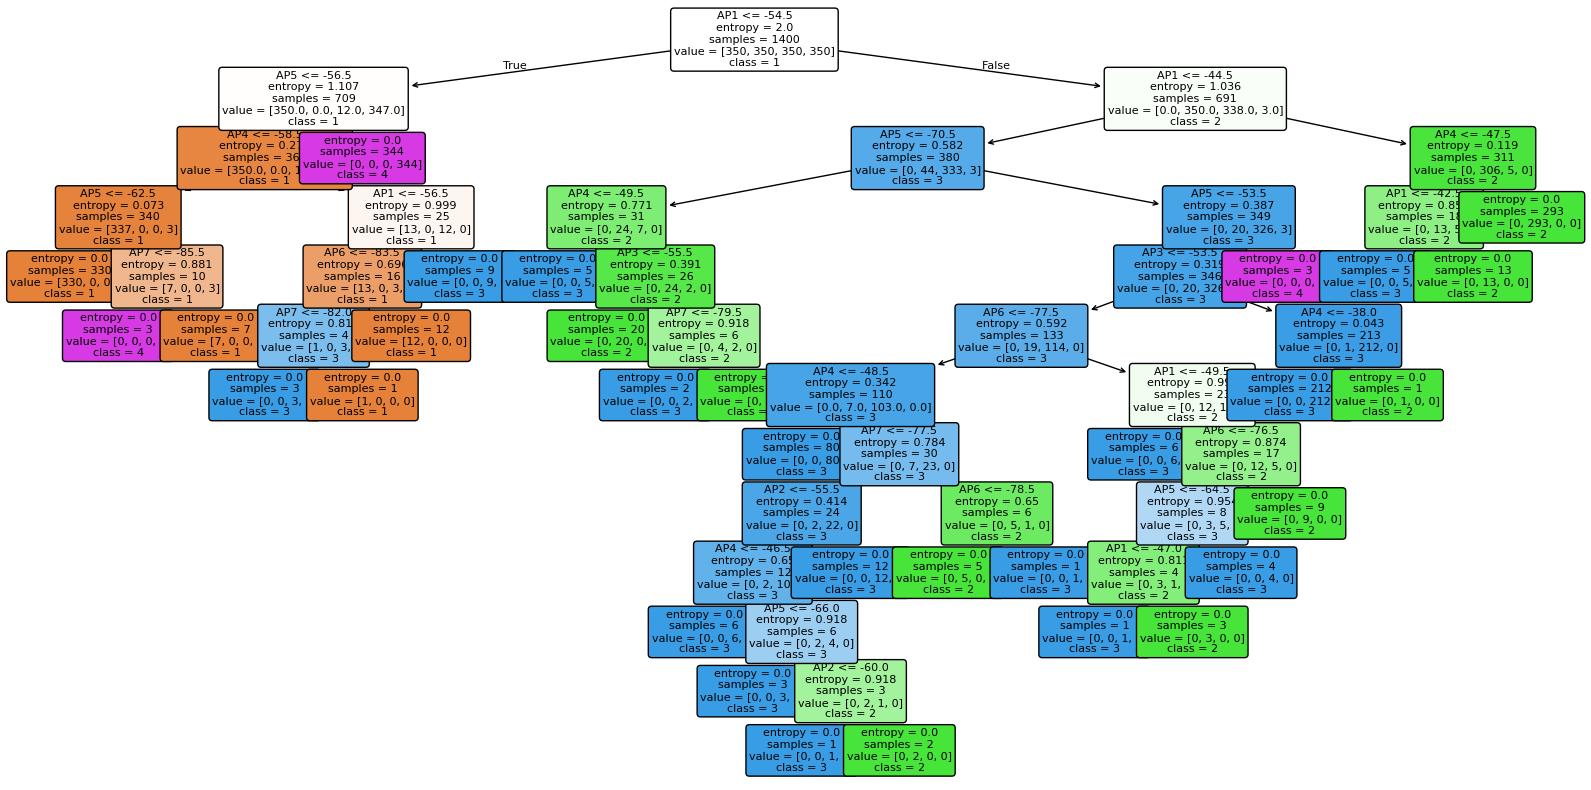

In [10]:
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

profundidade = clf.get_depth()
n_folhas = clf.get_n_leaves()
raiz_idx = clf.tree_.feature[0]

print(f"Profundidade da árvore: {profundidade}")
print(f"Número de nós folha: {n_folhas}")
print(f"Atributo do nó raiz: {feature_names[raiz_idx]}")

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=feature_names, class_names=[str(c) for c in clf.classes_], filled=True, rounded=True, fontsize=8)
plt.show()

**Resposta:** A árvore de decisão treinada teve profundidade 12 e 31 nós folha. O atributo utilizado no nó raiz foi o AP1, o que indica que ele é o que melhor separa as classes logo de início, sendo, portanto, o mais relevante para a divisão inicial dos dados.

### <font color='#2D9CDB'>Q8) Utilize a árvore de decisão treinada para realizar predições sobre o conjunto de teste. Em seguida, calcule a acurácia do modelo e apresente a matriz de confusão correspondente. Com base nos resultados obtidos, analise o desempenho do classificador e identifique quais salas foram classificadas com maior e menor precisão.</font>

Acurácia no conjunto de teste: 0.9667


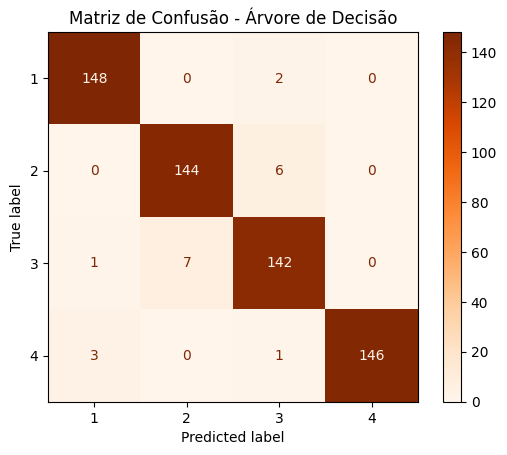

In [16]:
y_pred = clf.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acuracia:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Oranges')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

**Resposta:** O modelo obteve uma acurácia de 96,67% no conjunto de teste. Analisando a matriz de confusão, a sala 1 foi classificada com maior precisão, apresentando apenas 2 erros de classificação, enquanto a sala 3 apresentou mais confusões com outras salas, 8 erros, indicando maior sobreposição nos valores de RSSI entre esses ambientes, mas ainda com uma alta acurácia(94,7%).

### <font color='#2D9CDB'>Q9) Treine novas árvores de decisão limitando a profundidade máxima (`max_depth`) aos valores de 1 a 15. Para cada modelo, calcule a acurácia nos conjuntos de treinamento e teste. Em seguida, organize os resultados em uma tabela e construa um gráfico comparando as acurácias obtidas. Com base nos resultados, analise como a profundidade influencia a complexidade e o desempenho do modelo. Por fim, identifique se há evidências de sobreajuste e indique qual profundidade parece oferecer o melhor equilíbrio entre capacidade de aprendizado e generalização.</font>

In [17]:
resultados = []

for depth in range(1, 16):
    modelo = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    modelo.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test = accuracy_score(y_test, modelo.predict(X_test))

    resultados.append({'max_depth': depth, 'acuracia_treino': acc_train, 'acuracia_teste': acc_test})

df_resultados = pd.DataFrame(resultados)
df_resultados

,max_depth,acuracia_treino,acuracia_teste
0,1,0.500000,0.500000
1,2,0.952143,0.958333
2,3,0.964286,0.965000
3,4,0.980000,0.973333
4,5,0.983571,0.968333
5,6,0.987143,0.970000
6,7,0.991429,0.971667
7,8,0.995714,0.970000
8,9,0.997857,0.970000
9,10,0.998571,0.970000


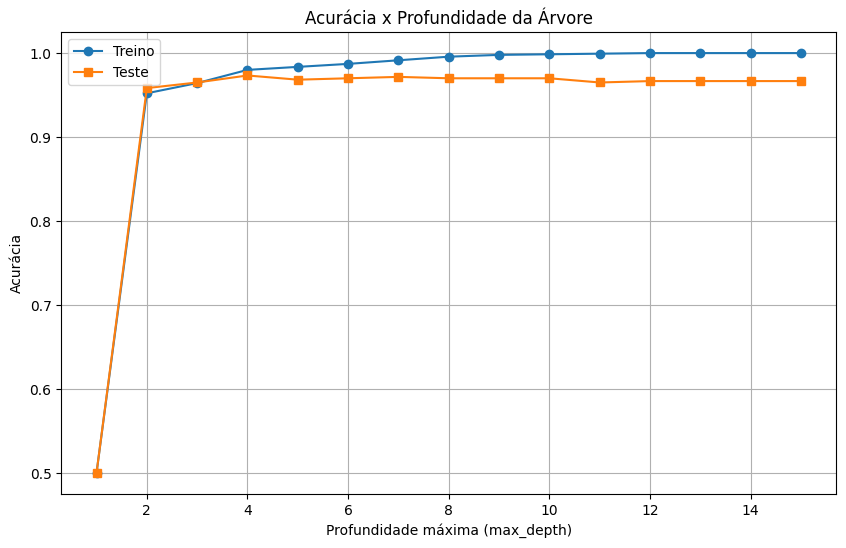

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(df_resultados['max_depth'], df_resultados['acuracia_treino'], 'o-', label='Treino')
plt.plot(df_resultados['max_depth'], df_resultados['acuracia_teste'], 's-', label='Teste')
plt.xlabel('Profundidade máxima (max_depth)')
plt.ylabel('Acurácia')
plt.title('Acurácia x Profundidade da Árvore')
plt.legend()
plt.grid()
plt.show()

**Resposta:** É possível observar que a acurácia de treino cresce continuamente conforme aumenta a profundidade, partindo de 50% (profundidade 1) e chegando a 100% a partir da profundidade 12. Já a acurácia de teste cresce até a profundidade 4 (97,33%), e a partir daí estabiliza e até apresenta leve queda, chegando a 96,5%~96,7% nas profundidades mais altas, mesmo com a acurácia de treino em 100%. Esse comportamento é uma evidência de overfitting: a partir de certo ponto, a árvore passa a memorizar particularidades do conjunto de treino em vez de aprender padrões que generalizam para novos dados, aumentando a distância entre as duas curvas. A profundidade mais adequada é a 4ª, pois apresenta a maior acurácia de teste (97,33%) com a menor complexidade possível, evitando crescer a árvore além do necessário.

### <font color='#2D9CDB'>Q10) Utilizando a árvore de decisão treinada, obtenha a importância de cada atributo RSSI por meio da propriedade `feature_importances_`. Em seguida, construa um gráfico de barras ordenando os atributos do mais importante para o menos importante. Com base nos resultados, identifique quais pontos de acesso contribuíram mais para a classificação das salas e discuta por que alguns atributos podem ser mais relevantes do que outros para o problema de localização indoor.</font>

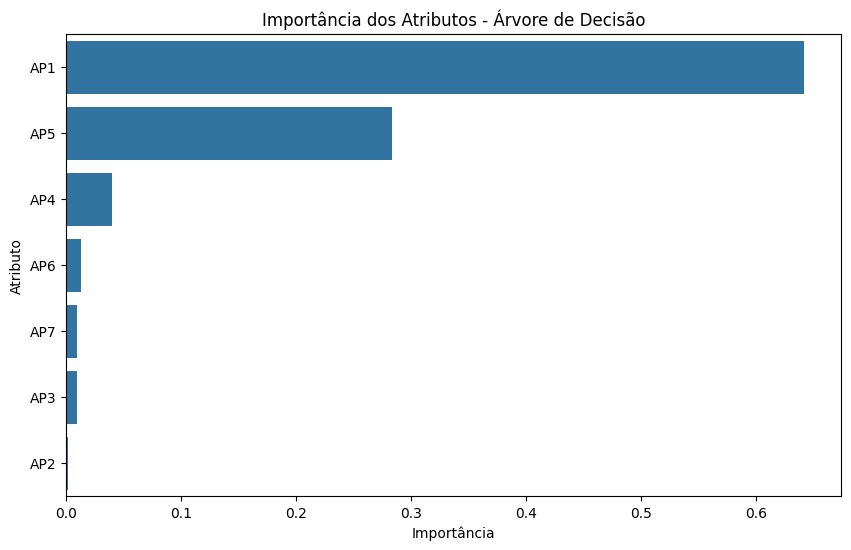

In [24]:
importancias = clf.feature_importances_

df_importancias = pd.DataFrame({
    'atributo': feature_names,
    'importancia': importancias
}).sort_values(by='importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias, x='importancia', y='atributo', orient='h')
plt.title('Importância dos Atributos - Árvore de Decisão')
plt.xlabel('Importância')
plt.ylabel('Atributo')
plt.show()

**Resposta:** Os atributos mais importantes para a classificação foram AP1 (64,2%) e AP5 (28,4%), somando juntos mais de 92% da importância total do modelo. Os demais atributos tiveram contribuição bem menor, todos abaixo de 5%, sendo AP2 praticamente irrelevante (0,17%). Isso indica que os pontos de acesso AP1 e AP5 captam sinais com maior poder discriminativo entre as salas. Eles provavelmente estão posicionados de forma que suas medições de RSSI variam de maneira mais clara e consistente de acordo com a localização, enquanto os demais APs têm sinais mais uniformes ou redundantes entre os diferentes ambientes, contribuindo pouco para diferenciar as salas.

# <font color='green'><u><b>Parte 3 - K-Means</b></u></font>

### <font color='#2D9CDB'>Q11) Diferentemente das árvores de decisão, o algoritmo k-Means não utiliza rótulos durante o treinamento. Pesquise brevemente sobre esse método e descreva, em um único parágrafo, o que é clusterização, qual é o objetivo do algoritmo k-Means, o significado de um centroide e como o algoritmo utiliza a distância entre as amostras para formar agrupamentos.</font>

**Resposta:** Clusterização é uma técnica de aprendizado não supervisionado que tem como objetivo agrupar amostras com características semelhantes entre si, sem o uso de rótulos previamente conhecidos. O algoritmo k-Means busca particionar o conjunto de dados em k grupos (clusters), de forma a minimizar a variância interna de cada grupo, ou seja, tornar as amostras de um mesmo cluster o mais parecidas possível entre si. Cada cluster é representado por um centroide, que corresponde à média das coordenadas de todas as amostras pertencentes àquele grupo. O algoritmo utiliza a distância, geralmente euclidiana, entre cada amostra e os centroides para definir os agrupamentos: cada amostra é atribuída ao cluster cujo centroide está mais próximo dela, e esse processo é repetido iterativamente, recalculando os centroides a cada iteração, até que as atribuições se estabilizem.

### <font color='#2D9CDB'>Q12) Considere os dois atributos mais importantes identificados na Q10. Construa um gráfico de dispersão utilizando essas variáveis, representando as amostras de cada sala com cores distintas e uma legenda apropriada. Com base na visualização obtida, analise a distribuição das amostras e discuta se existem agrupamentos naturais nos dados. Na sua opinião, seria possível identificar as diferentes salas sem utilizar os rótulos originais?</font>

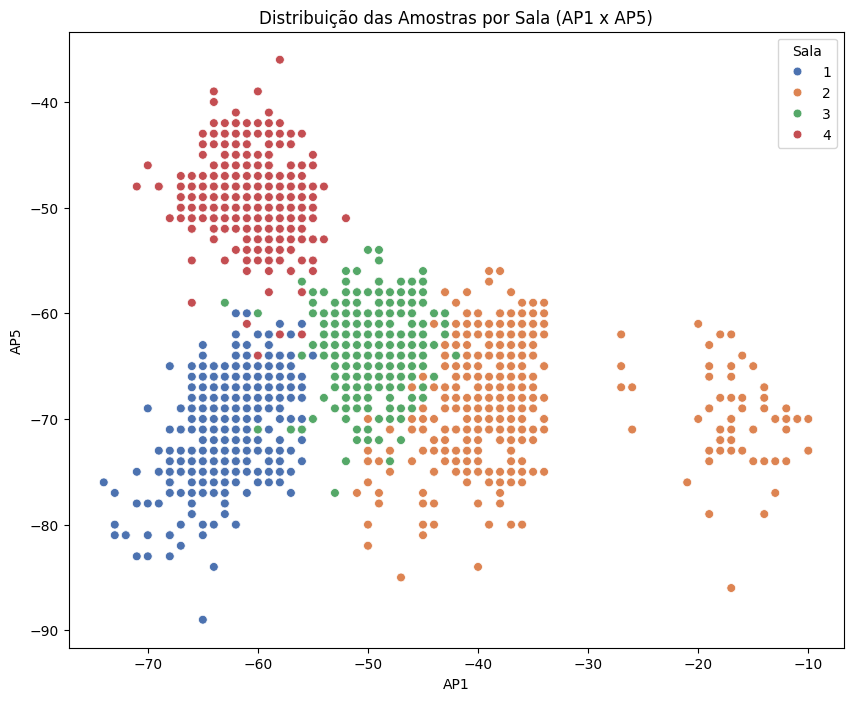

In [26]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='AP1', y='AP5', hue='Room', palette='deep', s=40)
plt.title('Distribuição das Amostras por Sala (AP1 x AP5)')
plt.xlabel('AP1')
plt.ylabel('AP5')
plt.legend(title='Sala')
plt.show()

**Resposta:** O gráfico de dispersão mostra que as amostras de cada sala formam agrupamentos visualmente bem definidos e separados entre si, mas com algumas sobreposições entre as classes. Isso indica que existe sim uma estrutura natural de agrupamento nos dados, mesmo sem considerar os rótulos originais. Dessa forma, seria possível identificar as diferentes salas apenas observando a distribuição espacial das amostras nos eixos AP1 e AP5, o que sugere que um algoritmo de clusterização não supervisionado, como o k-Means, tem boas chances de recuperar essa separação entre as salas com base apenas nesses dois atributos.

### <font color='#2D9CDB'>Q13) Antes de aplicar o algoritmo k-Means, é necessário definir o número de clusters (*k*). Utilize o Método do Cotovelo (Elbow Method) para avaliar valores de *k* entre 1 e 10. Para cada valor, calcule a inércia do modelo e construa um gráfico relacionando o número de clusters e a inércia obtida. Com base no gráfico, identifique o valor de *k* que parece mais adequado para este conjunto de dados e justifique sua escolha.</font>

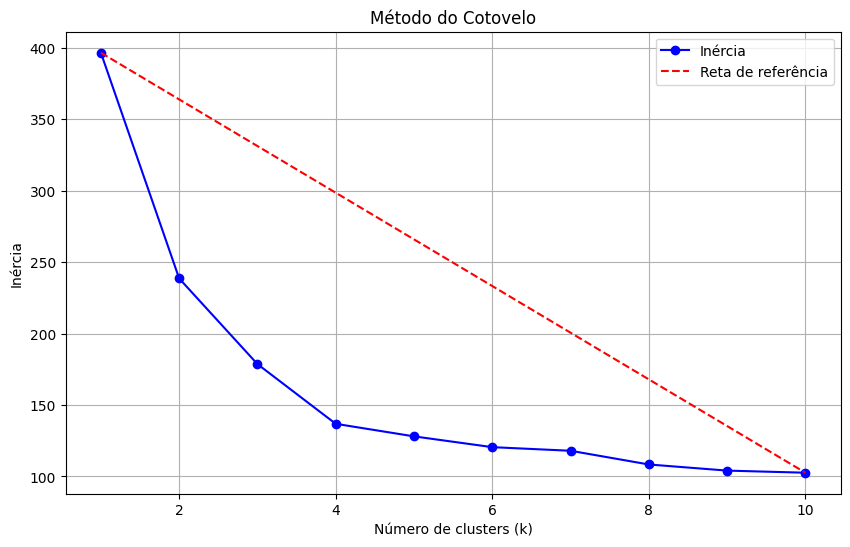

In [30]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[feature_names])

inercias = []
k_max = 10

for k in range(1, k_max + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

k_values = range(1, k_max + 1)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inercias, 'bo-', label='Inércia')

x = np.array([1, k_max])
y_vals = np.array([inercias[0], inercias[-1]])
a, b = np.polyfit(x, y_vals, 1)
plt.plot(x, a * x + b, 'r--', label='Reta de referência')

plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.legend()
plt.grid()
plt.show()

In [31]:
distancias = [abs(inercias[k-1] - (a * k + b)) for k in range(1, k_max + 1)]
k_otimo = np.argmax(distancias) + 1
print(f"Número ideal de clusters: k = {k_otimo}")

Número ideal de clusters: k = 4


**Resposta:** Com base no gráfico, o valor de k mais adequado é 4, identificado como o ponto da curva de inércia mais distante da reta de referência traçada entre os extremos (k=1 e k=10). Esse ponto representa o "cotovelo" da curva, onde adicionar mais clusters passa a reduzir a inércia de forma marginal, não justificando o aumento de complexidade.

### <font color='#2D9CDB'>Q14) Utilizando o valor de *k* identificado na Q13, treine um modelo k-Means empregando apenas os atributos AP1 e AP5. Em seguida, apresente as coordenadas dos centroides encontrados e construa um gráfico de dispersão mostrando as amostras coloridas de acordo com o cluster atribuído pelo algoritmo. Destaque também os centroides no gráfico. Com base nos resultados, analise a qualidade dos agrupamentos obtidos.</font>

In [32]:
X_kmeans = df[['AP1', 'AP5']].values

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_kmeans)

KMeans(n_clusters=4, random_state=42)

Centroides encontrados:
Cluster 0: AP1 = -34.84, AP5 = -67.81
Cluster 1: AP1 = -60.21, AP5 = -49.37
Cluster 2: AP1 = -62.38, AP5 = -70.42
Cluster 3: AP1 = -48.95, AP5 = -63.63


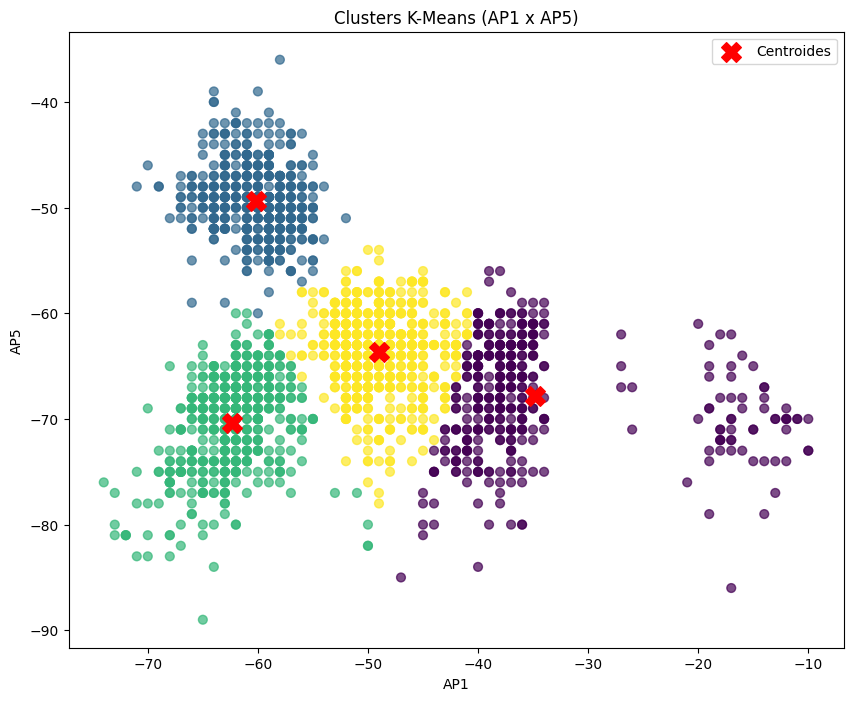

In [33]:
clusters = kmeans.labels_
centroides = kmeans.cluster_centers_

print("Centroides encontrados:")
for i, c in enumerate(centroides):
    print(f"Cluster {i}: AP1 = {c[0]:.2f}, AP5 = {c[1]:.2f}")

plt.figure(figsize=(10, 8))
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=clusters, cmap='viridis', s=40, alpha=0.7)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', s=200, marker='X', label='Centroides')
plt.xlabel('AP1')
plt.ylabel('AP5')
plt.title('Clusters K-Means (AP1 x AP5)')
plt.legend()
plt.show()

**Resposta:** Comparando os centroides encontrados com o gráfico de dispersão da Q12, os clusters formados se mostram bem definidos e visualmente próximos dos agrupamentos reais por sala, com os centroides posicionados no centro de cada nuvem de pontos. Isso indica que os agrupamentos obtidos são de boa qualidade, refletindo a separação natural já observada anteriormente entre as salas com base nos atributos AP1 e AP5.

### <font color='#2D9CDB'>Q15) Compare os clusters encontrados pelo k-Means com as salas reais do dataset. Para isso, construa uma <a href="https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html">tabela de contingência</a> relacionando cada sala aos clusters atribuídos pelo algoritmo. Em seguida, identifique qual cluster representa predominantemente cada sala e calcule a porcentagem de amostras associadas a esse agrupamento. Com base nos resultados, discuta quais salas foram mais facilmente identificadas pelo algoritmo e quais apresentaram maior grau de confusão com outros grupos.</font>

In [34]:
df_temp = df.copy()
df_temp['Cluster'] = clusters

tabela_contingencia = pd.crosstab(df_temp['Room'], df_temp['Cluster'])
tabela_contingencia

Cluster,0,1,2,3
Room,,,,
1,0,0,493,7
2,397,0,4,99
3,0,3,7,490
4,0,494,2,4


In [35]:
for sala in tabela_contingencia.index:
    cluster_predominante = tabela_contingencia.loc[sala].idxmax()
    qtd_predominante = tabela_contingencia.loc[sala].max()
    total_sala = tabela_contingencia.loc[sala].sum()
    porcentagem = (qtd_predominante / total_sala) * 100
    print(f"Sala {sala}: Cluster predominante = {cluster_predominante}, "
          f"{qtd_predominante}/{total_sala} amostras ({porcentagem:.2f}%)")

Sala 1: Cluster predominante = 2, 493/500 amostras (98.60%)
Sala 2: Cluster predominante = 0, 397/500 amostras (79.40%)
Sala 3: Cluster predominante = 3, 490/500 amostras (98.00%)
Sala 4: Cluster predominante = 1, 494/500 amostras (98.80%)


**Resposta:** A tabela de contingência mostra uma correspondência forte entre os clusters formados pelo k-Means e as salas reais. A Sala 4 foi a mais bem identificada, com 98,80% de suas amostras concentradas no Cluster 1, seguida de perto pela Sala 1 (98,60% no Cluster 2) e pela Sala 3 (98,00% no Cluster 3). A Sala 2, por outro lado, apresentou o pior resultado, com apenas 79,40% das amostras concentradas no seu cluster predominante (Cluster 0) — ou seja, cerca de 1 em cada 5 amostras dessa sala foi atribuída a outro cluster, provavelmente o cluster associado à Sala 3, dado que essas duas salas já haviam apresentado maior confusão na árvore de decisão (Q8). Isso indica que a Sala 2 tem um perfil de sinal RSSI menos distintivo, possivelmente por estar fisicamente próxima ou ter condições de propagação semelhantes às de salas vizinhas, dificultando sua separação tanto por métodos supervisionados quanto não supervisionados.

# <font color='green'><u><b>Parte 4 - Detecção de Anomalias</b></u></font>

### <font color='#2D9CDB'>Q16) Uma aplicação comum de algoritmos de clusterização é a detecção de anomalias. Em geral, amostras localizadas muito longe do centroide de seu cluster podem representar comportamentos incomuns ou situações atípicas. Utilizando os dois atributos mais importantes identificados na Q10, calcule a distância euclidiana de cada amostra ao centroide do cluster ao qual ela foi atribuída pelo k-Means. Em seguida, apresente um histograma dessas distâncias e informe os valores mínimo, máximo, médio e o desvio padrão observados. Com base nos resultados, discuta o que essas distâncias revelam sobre a compactação dos clusters encontrados.</font>

Distância mínima: 0.25
Distância máxima: 25.47
Distância média: 5.23
Desvio padrão: 3.67


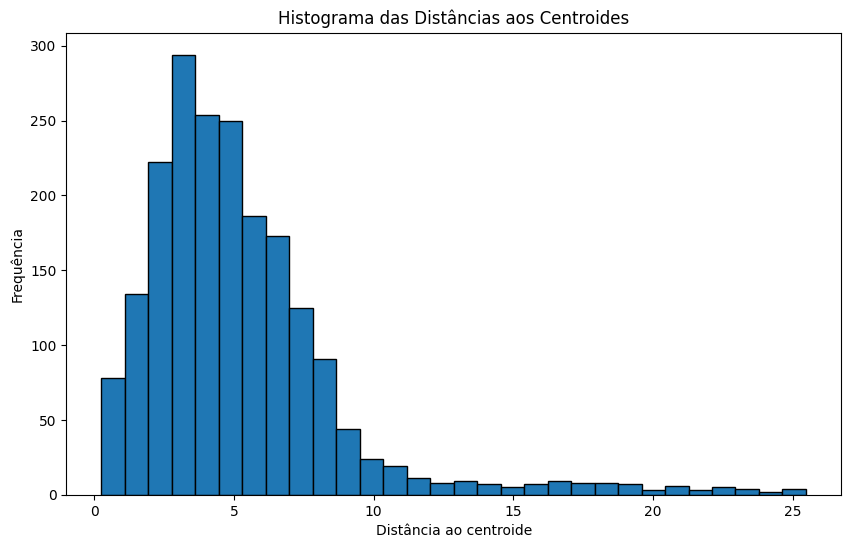

In [36]:
distancias_centroide = np.linalg.norm(X_kmeans - centroides[clusters], axis=1)

dist_min = distancias_centroide.min()
dist_max = distancias_centroide.max()
dist_media = distancias_centroide.mean()
dist_std = distancias_centroide.std()

print(f"Distância mínima: {dist_min:.2f}")
print(f"Distância máxima: {dist_max:.2f}")
print(f"Distância média: {dist_media:.2f}")
print(f"Desvio padrão: {dist_std:.2f}")

plt.figure(figsize=(10, 6))
plt.hist(distancias_centroide, bins=30, edgecolor='black')
plt.xlabel('Distância ao centroide')
plt.ylabel('Frequência')
plt.title('Histograma das Distâncias aos Centroides')
plt.show()

**Resposta:** As distâncias das amostras aos centroides de seus respectivos clusters variaram entre um mínimo de 0.25 e um máximo de 25.47, com média de 5.23 e desvio padrão de 3.67. O histograma mostra que a maior parte das amostras está concentrada em distâncias relativamente baixas, próximas da média, formando uma cauda mais longa à direita com poucas amostras bem mais distantes do centroide. Isso indica que os clusters são, em geral, razoavelmente compactos, mas com a presença de algumas observações mais dispersas, que são candidatas naturais a serem classificadas como anomalias.

### <font color='#2D9CDB'>Q17) Considere que amostras muito distantes do centroide de seu cluster podem ser classificadas como potenciais anomalias. Utilize o percentil de 95% das distâncias calculadas na Q16 como limiar de detecção. Em seguida, identifique todas as amostras cuja distância ao centroide seja superior a esse valor, informe quantas anomalias foram encontradas e apresente as cinco amostras mais distantes de seus respectivos centroides. Com base nos resultados, discuta se o critério adotado parece adequado para identificar observações atípicas.</font>

In [38]:
limiar_95 = np.percentile(distancias_centroide, 95)
print(f"Limiar: {limiar_95:.2f}")

Limiar: 11.59


In [39]:
anomalias_mask = distancias_centroide > limiar_95
n_anomalias = anomalias_mask.sum()
print(f"Número de anomalias encontradas: {n_anomalias}")

df_temp['distancia_centroide'] = distancias_centroide
df_temp[anomalias_mask].sort_values(by='distancia_centroide', ascending=False).head(5)

Número de anomalias encontradas: 100


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room,Cluster,distancia_centroide
609,-17,-63,-65,-27,-86,-72,-74,2,0,25.474774
769,-10,-57,-57,-36,-73,-82,-72,2,0,25.373139
873,-10,-58,-62,-20,-73,-76,-74,2,0,25.373139
870,-10,-58,-54,-18,-70,-72,-73,2,0,24.933279
932,-11,-59,-60,-27,-70,-74,-71,2,0,23.937297


**Resposta:** Utilizando o percentil 95% das distâncias como limiar (valor de 11.59), foram identificadas 100 amostras como potenciais anomalias, número exatamente coerente com o esperado para esse percentil (5% das 2000 amostras totais). As cinco amostras mais distantes de seus centroides pertencem todas à Sala 2, com distâncias entre 23.94 e 25.47, o que é bem acima da média geral(5.23) e do próprio limiar. Esse resultado reforça uma observação já feita anteriormente de que a Sala 2 é a que apresenta maior variabilidade nos sinais RSSI, sendo também a sala com pior desempenho tanto na árvore de decisão quanto no agrupamento pelo k-Means. O critério adotado parece adequado como uma primeira abordagem, pois é simples, baseado em uma medida estatística objetiva e captura exatamente a proporção esperada de amostras extremas, embora seja sensível à escolha do percentil.

### <font color='#2D9CDB'>Q18) Construa um gráfico de dispersão utilizando os dois atributos empregados pelo k-Means e destaque as anomalias identificadas na Q17. Represente também os centroides dos clusters. Com base na visualização obtida, avalie se as amostras classificadas como anômalas encontram-se em regiões afastadas dos centroides e discuta se os resultados são coerentes com o critério de detecção adotado.</font>

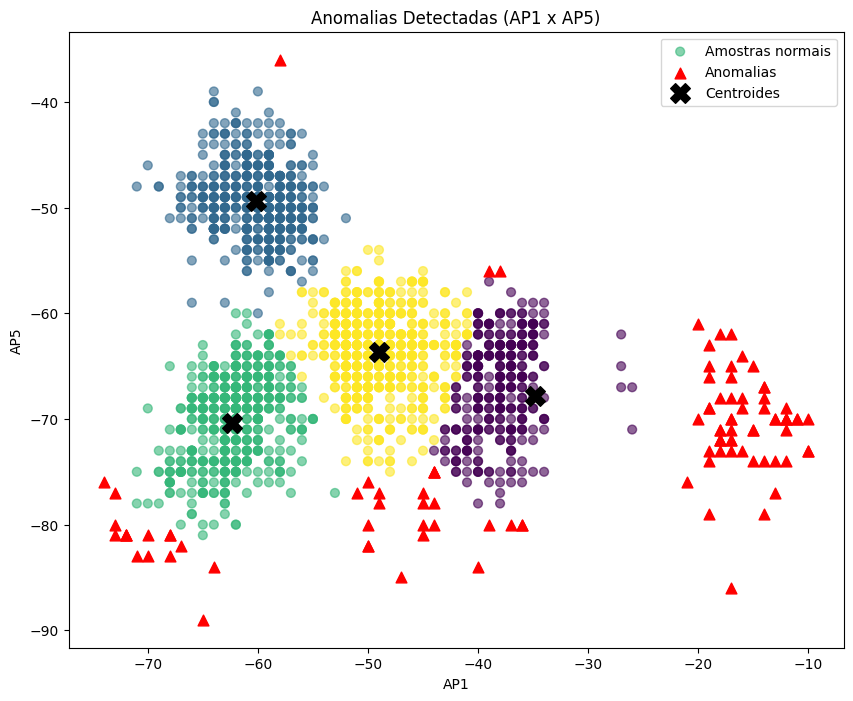

In [40]:
plt.figure(figsize=(10, 8))
plt.scatter(X_kmeans[~anomalias_mask, 0], X_kmeans[~anomalias_mask, 1], c=clusters[~anomalias_mask], cmap='viridis', s=40, alpha=0.6, label='Amostras normais')
plt.scatter(X_kmeans[anomalias_mask, 0], X_kmeans[anomalias_mask, 1], c='red', s=60, marker='^', label='Anomalias')
plt.scatter(centroides[:, 0], centroides[:, 1], c='black', s=200, marker='X', label='Centroides')
plt.xlabel('AP1')
plt.ylabel('AP5')
plt.title('Anomalias Detectadas (AP1 x AP5)')
plt.legend()
plt.show()

**Resposta:** O gráfico mostra que as amostras classificadas como anomalias se concentram nas regiões periféricas dos clusters, afastadas dos respectivos centroides, especialmente nas bordas e nas áreas de transição entre clusters vizinhos. Isso é coerente com o critério de detecção adotado, já que o método se baseia justamente na distância ao centroide. Visualmente, fica claro que essas amostras realmente representam casos atípicos dentro de seus grupos, validando a abordagem utilizada.

### <font color='#2D9CDB'>Q19) O limiar utilizado para detectar anomalias influencia diretamente a quantidade de observações classificadas como atípicas. Repita o procedimento da Q17 utilizando os percentis 90%, 95% e 99% das distâncias aos centroides. Para cada caso, registre o valor do limiar e o número de anomalias detectadas. Organize os resultados em uma tabela e discuta como a escolha do percentil afeta a sensibilidade do detector de anomalias.</font>

In [41]:
percentis = [90, 95, 99]
resultados_percentis = []

for p in percentis:
    limiar = np.percentile(distancias_centroide, p)
    n_anom = (distancias_centroide > limiar).sum()
    resultados_percentis.append({'percentil': p, 'limiar': limiar, 'n_anomalias': n_anom})

df_percentis = pd.DataFrame(resultados_percentis)
df_percentis

,percentil,limiar,n_anomalias
0,90,8.565266,200
1,95,11.588763,100
2,99,20.853090,20


**Resposta:** Comparando os três percentis avaliados, observa-se que quanto maior o percentil utilizado como limiar, menor o número de amostras classificadas como anomalias, e maior o valor da distância exigida para essa classificação. No percentil 90%, o limiar é mais baixo e captura cerca de 200 amostras (10% do total), no percentil 95%, o limiar sobe e o número de anomalias cai para 100 (5%), no percentil 99%, o limiar é o mais alto e apenas cerca de 20 amostras (1%) são consideradas anômalas. Isso mostra que a escolha do percentil define diretamente a sensibilidade do detector: percentis mais baixos tornam o critério mais permissivo, sinalizando mais observações como atípicas (incluindo possíveis falsos positivos), enquanto percentis mais altos tornam o critério mais rigoroso, focando apenas nos casos mais extremos, mas correndo o risco de deixar passar anomalias reais (falsos negativos).

# <font color='green'><u><b>Parte 5 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q20) Ao longo desta atividade foram exploradas técnicas de aprendizado supervisionado (Árvores de Decisão) e não supervisionado (k-Means), além de uma abordagem simples para detecção de anomalias baseada na distância aos centroides. Compare essas três aplicações quanto aos seus objetivos, à utilização de rótulos durante o treinamento, aos resultados produzidos e às situações em que cada uma delas é mais adequada. Por fim, discuta como essas técnicas poderiam ser utilizadas em conjunto em um sistema de localização indoor baseado em sinais Wi-Fi.</font>

**Resposta:** As três técnicas têm propósitos bem diferentes entre si. A árvore de decisão é supervisionada, ou seja, precisa dos rótulos das salas pra aprender a classificar — o objetivo dela é prever em qual sala o dispositivo está com base nas leituras de RSSI, e nesse trabalho ela chegou a 96,7% de acurácia no teste. Já o k-Means não usa rótulo nenhum, ele só olha pra proximidade entre as amostras e tenta descobrir agrupamentos sozinho. Isso fica mais interessante em situações onde a gente não tem rótulo disponível, ou quando quer conferir se uma classe que já existe (no caso, a sala) realmente aparece de forma natural nos dados — e foi exatamente isso que vimos ao comparar os clusters com as salas reais na Q15.

A detecção de anomalias nem é bem um algoritmo separado, é mais uma aplicação em cima do k-Means: olhando a distância de cada amostra até o centroide do seu cluster, dá pra sinalizar leituras estranhas sem precisar de rótulo nem de um modelo novo, o que é útil pra pegar erros de hardware ou interferência no sinal.

Num sistema real de localização indoor com Wi-Fi, essas técnicas dariam pra combinar: o k-Means e a detecção de anomalias entrariam antes, limpando os dados de leituras ruins ou inconsistentes, e a árvore de decisão treinaria em cima desse conjunto já filtrado, sendo usada depois em tempo real pra classificar a posição do dispositivo — um modelo leve e fácil de interpretar pra rodar em produção.

# Parte extra
Fiquei curioso em como a Q12 fica em 3 dimensões, fiz com que o terceiro eixo fosse AP4, que foi a terceira mais importante na Q10, e pedi para o Claude fazer o código de um gráfico interativo de 3 dimensões, fica o código de curiosidade

In [42]:
! pip install plotly

In [43]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='AP1', y='AP5', z='AP4',
    color=df['Room'].astype(str),
    title='Distribuição das Amostras em 3D (AP1, AP5, AP4)',
    labels={'color': 'Sala'},
    opacity=0.7
)
fig.update_traces(marker=dict(size=4))
fig.show()

## Com os centróides

In [44]:
from sklearn.cluster import KMeans
import plotly.graph_objects as go

X_3d = df[['AP1', 'AP5', 'AP4']].values

kmeans_3d = KMeans(n_clusters=4, random_state=42)
kmeans_3d.fit(X_3d)

clusters_3d = kmeans_3d.labels_
centroides_3d = kmeans_3d.cluster_centers_

fig = go.Figure()

# Amostras coloridas por cluster
fig.add_trace(go.Scatter3d(
    x=X_3d[:, 0], y=X_3d[:, 1], z=X_3d[:, 2],
    mode='markers',
    marker=dict(size=3, color=clusters_3d, colorscale='Viridis', opacity=0.6),
    name='Amostras'
))

# Centroides
fig.add_trace(go.Scatter3d(
    x=centroides_3d[:, 0], y=centroides_3d[:, 1], z=centroides_3d[:, 2],
    mode='markers',
    marker=dict(size=10, color='red', symbol='diamond'),
    name='Centroides'
))

fig.update_layout(
    title='Clusters K-Means em 3D (AP1, AP5, AP4)',
    scene=dict(xaxis_title='AP1', yaxis_title='AP5', zaxis_title='AP4'),
    legend=dict(x=0.02, y=0.98)
)
fig.show()